In [88]:
import tensorflow as tf
from keras.src.layers import Dropout
from tensorflow.keras import layers
import tensorboard as tb
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import SplineTransformer
import glob
import os

pjm_hourly_est = pd.read_csv('pjm_hourly_est.csv')

print(pjm_hourly_est.head())


              Datetime  AEP  COMED  DAYTON  DEOK  DOM  DUQ  EKPC  FE  NI  \
0  1998-12-31 01:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
1  1998-12-31 02:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
2  1998-12-31 03:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
3  1998-12-31 04:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
4  1998-12-31 05:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   

   PJME  PJMW  PJM_Load  
0   NaN   NaN   29309.0  
1   NaN   NaN   28236.0  
2   NaN   NaN   27692.0  
3   NaN   NaN   27596.0  
4   NaN   NaN   27888.0  


              Datetime  AEP  COMED  DAYTON  DEOK  DOM  DUQ  EKPC  FE  NI  \
0  1998-12-31 01:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
1  1998-12-31 02:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
2  1998-12-31 03:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
3  1998-12-31 04:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
4  1998-12-31 05:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   

   PJME  PJMW  PJM_Load  
0   NaN   NaN   29309.0  
1   NaN   NaN   28236.0  
2   NaN   NaN   27692.0  
3   NaN   NaN   27596.0  
4   NaN   NaN   27888.0  


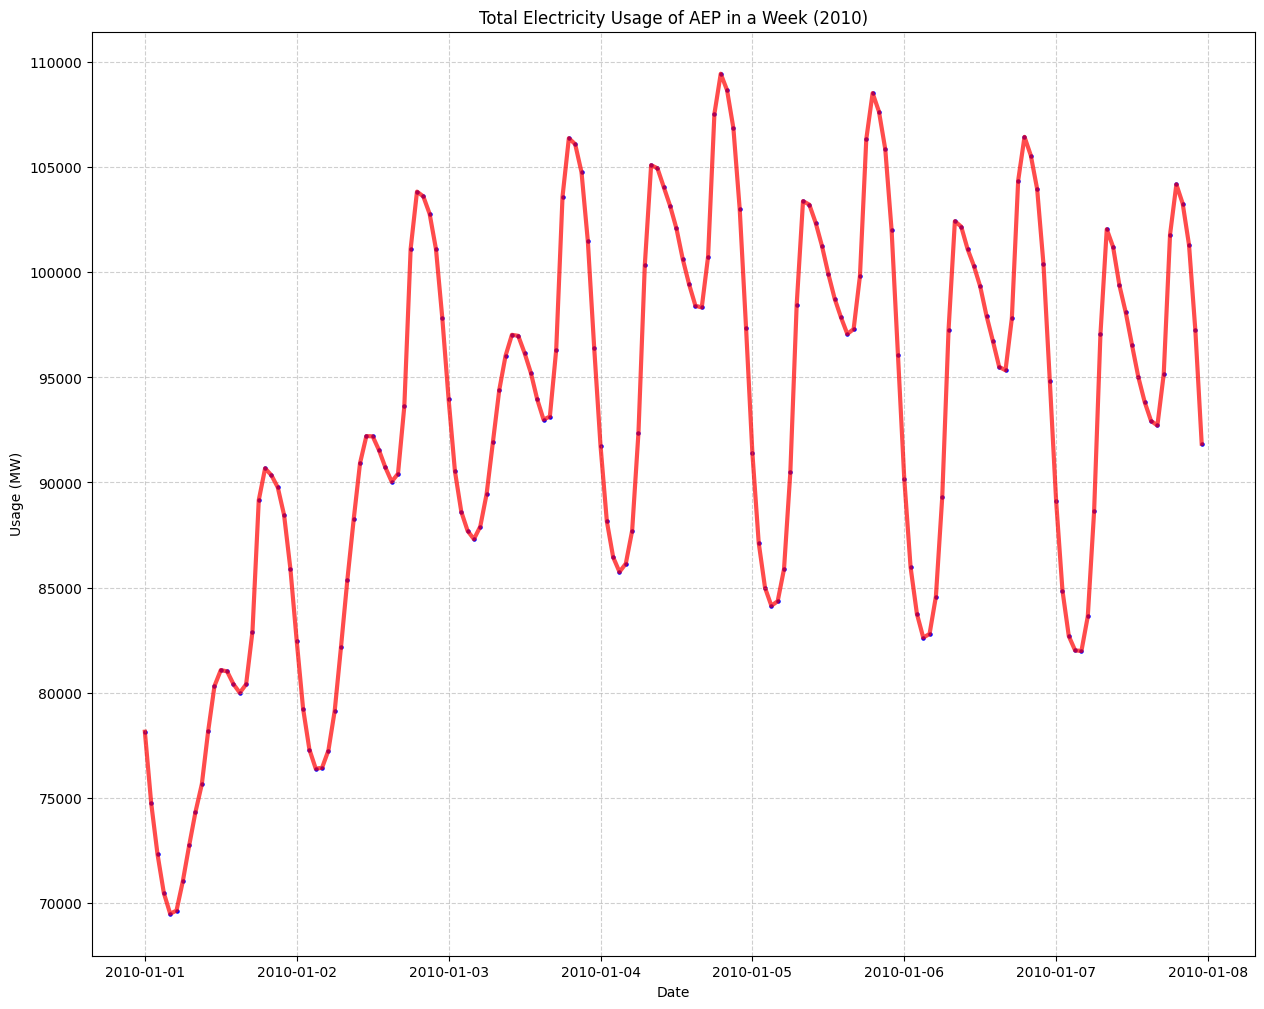

In [89]:
import matplotlib.pyplot as plt

pjm_hourly_AEP = pd.read_csv('pjm_hourly_est.csv')

print(pjm_hourly_AEP.head())

test_data = pjm_hourly_AEP.copy()
numeric_cols = test_data.select_dtypes(include=[np.number]).columns

test_data[numeric_cols] = test_data[numeric_cols].fillna(0)
test_data['total_usage'] = test_data[numeric_cols].sum(axis=1, skipna=True)

test_data = test_data[['Datetime', 'total_usage']]



#CHANGE THESE VALUES FOR DIFFERENT TIMESPANS
start_datetime = pd.to_datetime('2010-01-01 00:00:00')
end_datetime = pd.to_datetime('2010-01-07 23:00:00')

format_string = "%Y-%m-%d %H:%M:%S"

test_data['Datetime'] = pd.to_datetime(test_data['Datetime'], format='%Y-%m-%d %H:%M:%S')

mask = (test_data['Datetime'] >= start_datetime) & (test_data['Datetime'] <= end_datetime)
clean_df = test_data.loc[mask]

plt.figure(figsize=(15, 12))

clean_df = clean_df.sort_values(by='Datetime')


#scatter and lineplots
plt.scatter(clean_df['Datetime'], clean_df['total_usage'], color='blue', s=5, alpha=1)
plt.plot(clean_df['Datetime'], clean_df['total_usage'], color='red', linewidth=3, alpha=0.7)



#axis/format of plot
plt.title('Total Electricity Usage of AEP in a Week (2010)')
plt.xlabel('Date')
plt.ylabel('Usage (MW)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

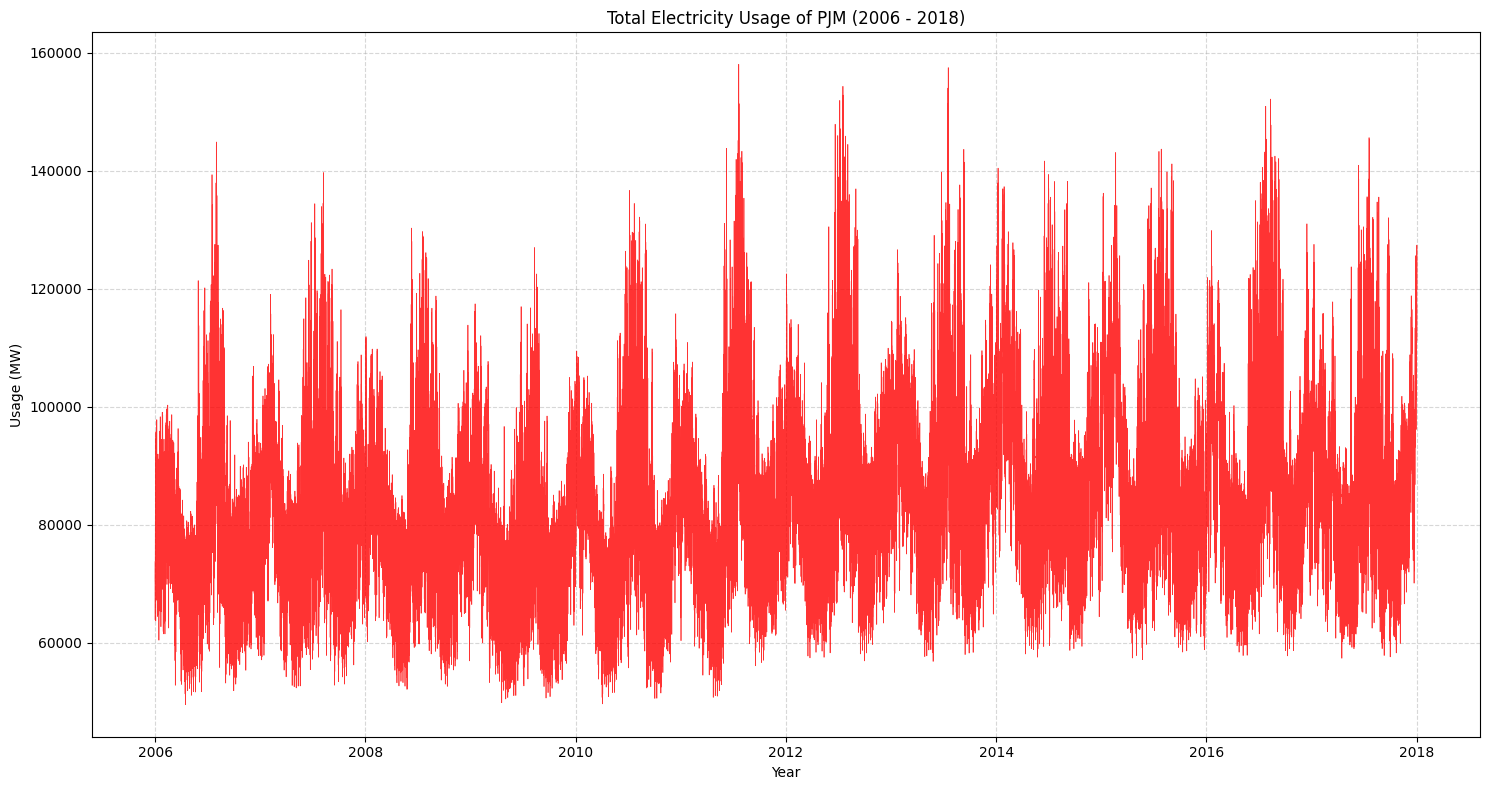

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
pjm_hourly_AEP = pd.read_csv('pjm_hourly_est.csv')

# 2. Process usage (using your method of summing numeric columns)
test_data = pjm_hourly_AEP.copy()
numeric_cols = test_data.select_dtypes(include=[np.number]).columns
test_data[numeric_cols] = test_data[numeric_cols].fillna(0)
test_data['total_usage'] = test_data[numeric_cols].sum(axis=1, skipna=True)

# 3. Convert 'Datetime' to datetime objects
test_data['Datetime'] = pd.to_datetime(test_data['Datetime'], format='%Y-%m-%d %H:%M:%S')

# 4. SET NEW TIMESPAN HERE
start_datetime = pd.to_datetime('2006-01-01 00:00:00')
end_datetime = pd.to_datetime('2018-01-01 23:00:00')

# 5. Apply the mask and sort the data
mask = (test_data['Datetime'] >= start_datetime) & (test_data['Datetime'] <= end_datetime)
plot_data = test_data.loc[mask].sort_values(by='Datetime')

# 6. Plotting
plt.figure(figsize=(15, 8))

# Use a smaller linewidth for long durations to prevent the plot from looking too "busy"
plt.plot(plot_data['Datetime'], plot_data['total_usage'], color='red', linewidth=0.5, alpha=0.8)

plt.title('Total Electricity Usage of PJM (2006 - 2018)')
plt.xlabel('Year')
plt.ylabel('Usage (MW)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

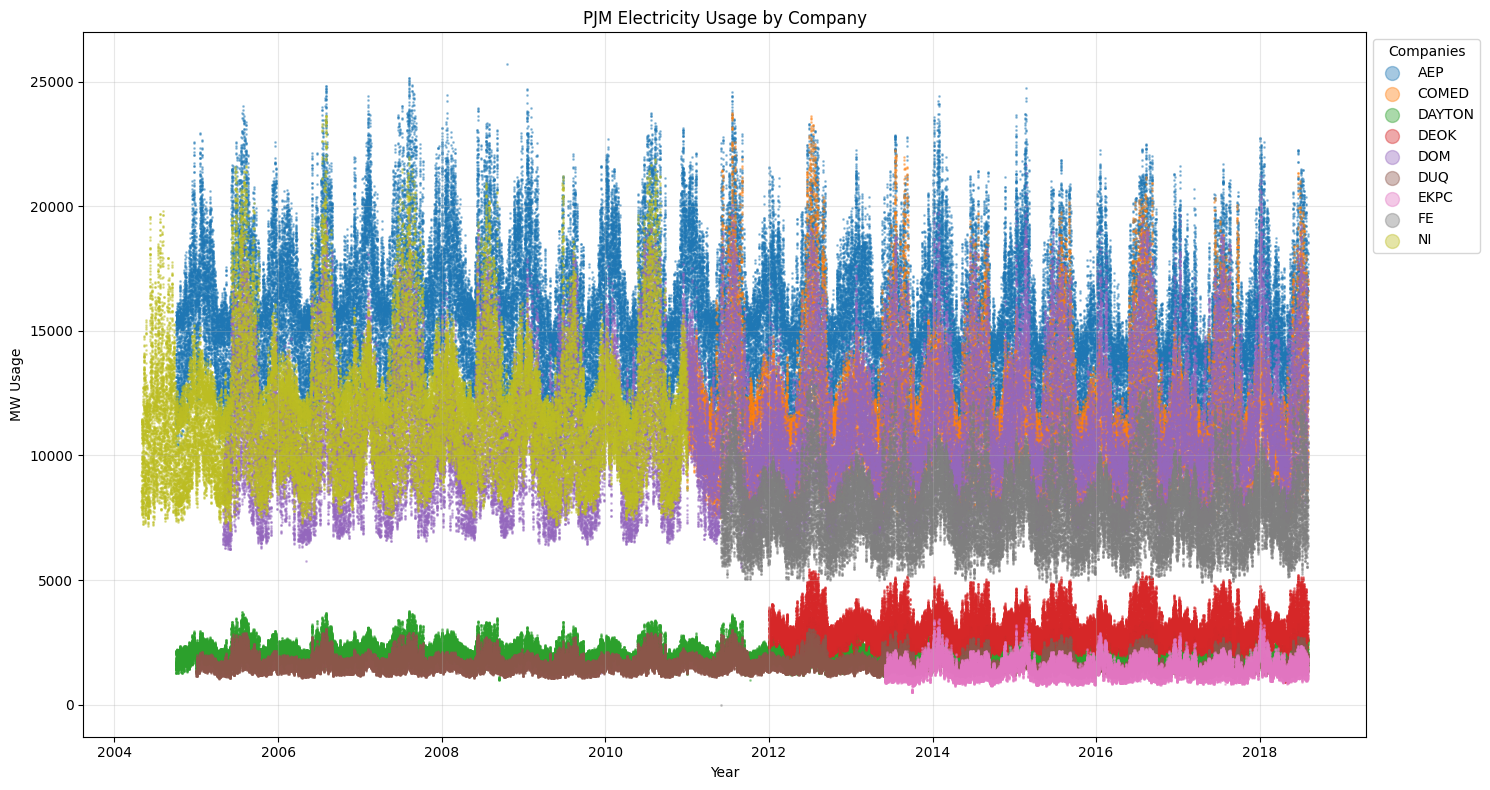

In [91]:
# Get a list of all CSV files in your directory
folder_path = 'electricity-data/*.csv'
files = glob.glob(folder_path)

all_data = []

for file in files:
    # Read the CSV
    df = pd.read_csv(file)
    
    # Standardize column names (PJM files often use the company name as the MW column)
    # This renames whatever the second column is to 'total_usage'
    df.columns = ['Datetime', 'total_usage']
    
    base_name = os.path.basename(file)
    # Extract company name from filename (e.g., "AEP.csv" -> "AEP")
    company_name = base_name.split('_')[0]
    df['Company'] = company_name
    
    # Convert to datetime
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    
    all_data.append(df)

# Combine everything into one giant dataframe
combined_df = pd.concat(all_data, ignore_index=True)




plt.figure(figsize=(15, 8))

# 1. Get the list of unique company names from your combined dataframe
companies = combined_df['Company'].unique()

# 2. Loop through each company and plot them separately
for company in companies:
    # Filter the dataframe for just this company
    subset = combined_df[combined_df['Company'] == company]
    
    # Plot the subset. Matplotlib will automatically cycle colors for each call.
    plt.scatter(subset['Datetime'], 
                subset['total_usage'], 
                s=1,           # Small points so they don't overlap too much
                alpha=0.4,     # Transparency to see density
                label=company) # This label is what the legend uses

# 3. Add the legend so you can tell which color is which
# We place it outside the plot (bbox_to_anchor) so it doesn't cover the data
plt.legend(markerscale=10, title="Companies", loc='upper left', bbox_to_anchor=(1, 1))

plt.title('PJM Electricity Usage by Company')
plt.xlabel('Year')
plt.ylabel('MW Usage')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Number of components needed for 95% variance: 20


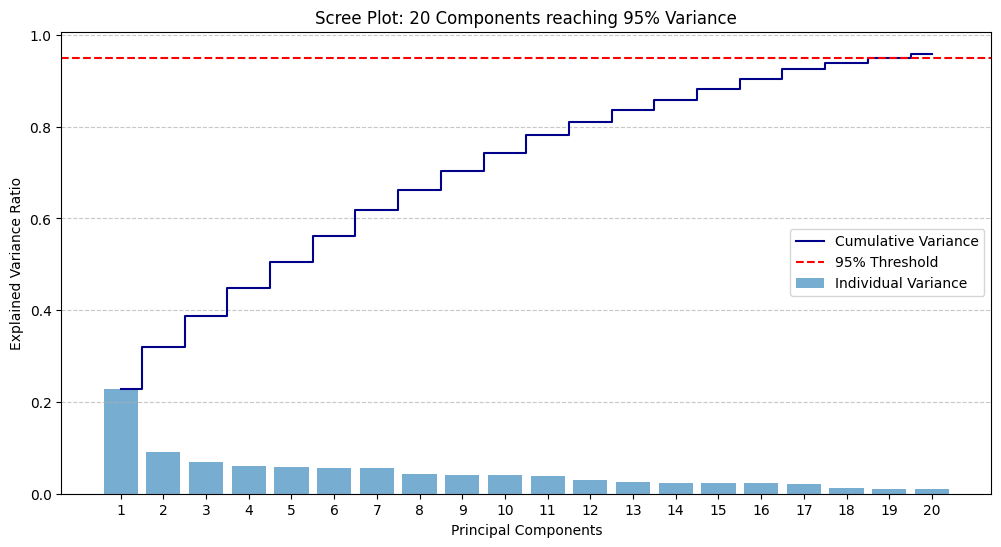

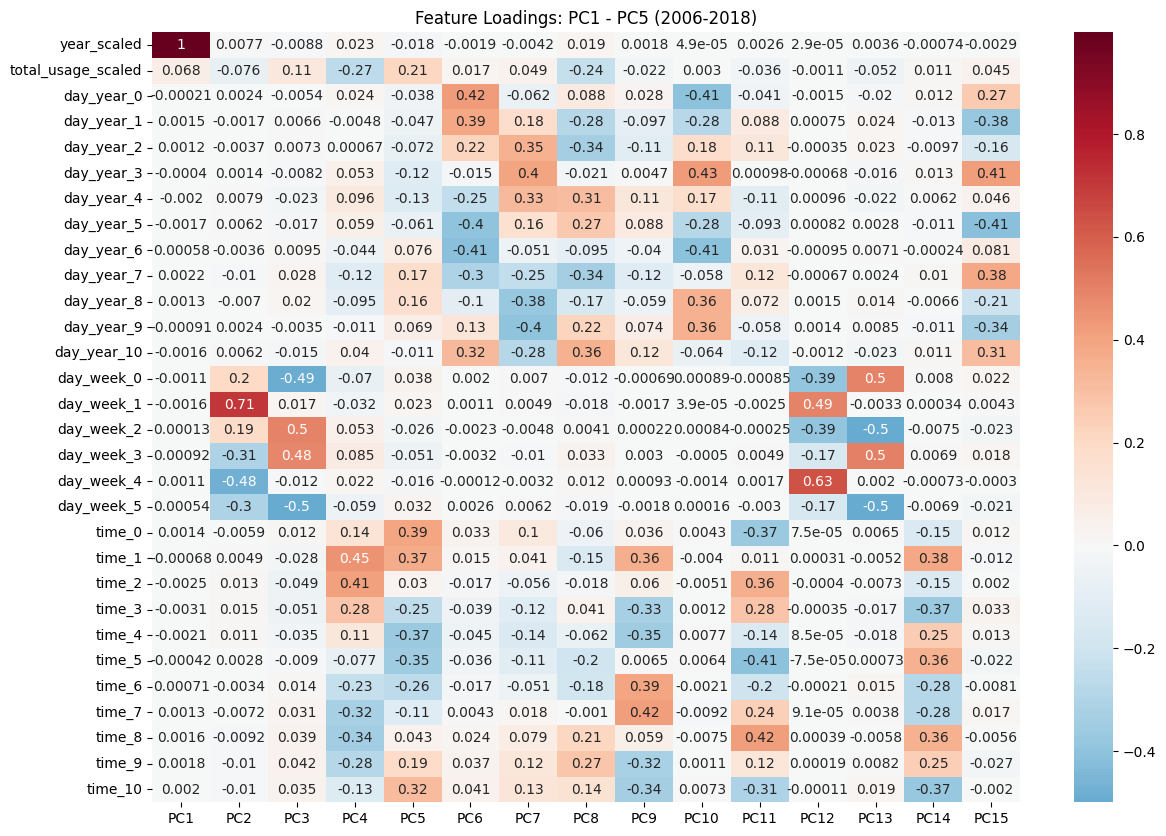

In [92]:
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Prepare the working dataframe
df_subset = plot_data.copy()
df_subset['year'] = df_subset['Datetime'].dt.year
df_subset['day_of_year'] = df_subset['Datetime'].dt.dayofyear
df_subset['day_of_week'] = df_subset['Datetime'].dt.dayofweek
df_subset['time_of_day'] = df_subset['Datetime'].dt.hour

# 2. Scaling
input_scaler = MinMaxScaler(feature_range=(-1, 1))
output_scaler = MinMaxScaler(feature_range=(0, 1))

df_subset['year_scaled'] = input_scaler.fit_transform(df_subset[['year']])
df_subset['total_usage_scaled'] = output_scaler.fit_transform(df_subset[['total_usage']])

# 3. Apply Periodic Splines (Periodic=True handles the 23:00 -> 00:00 wrap-around)
# Note: This automatically drops one feature per set to prevent redundancy
periodic_spline = SplineTransformer(n_knots=12, degree=3, extrapolation="periodic")
week_spline = SplineTransformer(n_knots=7, degree=3, extrapolation="periodic")

# Transform and create DataFrames
day_year_feats = pd.DataFrame(periodic_spline.fit_transform(df_subset[['day_of_year']]), 
                              index=df_subset.index).add_prefix('day_year_')
day_week_feats = pd.DataFrame(week_spline.fit_transform(df_subset[['day_of_week']]), 
                              index=df_subset.index).add_prefix('day_week_')
time_feats = pd.DataFrame(periodic_spline.fit_transform(df_subset[['time_of_day']]), 
                           index=df_subset.index).add_prefix('time_')

# Combine into final PCA input matrix
df_pca_input = pd.concat([df_subset[['year_scaled', 'total_usage_scaled']], 
                          day_year_feats, day_week_feats, time_feats], axis=1)

# 1.
# 1. Initialize PCA to capture 95% of the variance
pca_95 = PCA(n_components=0.95)
pca_results_95 = pca_95.fit_transform(df_pca_input)

n_components_found = pca_95.n_components_
print(f"Number of components needed for 95% variance: {n_components_found}")

# 2. Calculate the cumulative variance for plotting
cumulative_variance = np.cumsum(pca_95.explained_variance_ratio_)


# 2. Scree Plot
plt.figure(figsize=(12, 6))

# Plot bar and step
plt.bar(range(1, n_components_found + 1), pca_95.explained_variance_ratio_, alpha=0.6, label='Individual Variance')
plt.step(range(1, n_components_found + 1), cumulative_variance, where='mid', label='Cumulative Variance', color='darkblue')

# Add the 95% threshold line
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')

plt.title(f'Scree Plot: {n_components_found} Components reaching 95% Variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, n_components_found + 1)) # Shows every component index
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Loadings Heatmap
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(pca.components_))], 
                        index=df_pca_input.columns)

plt.figure(figsize=(14, 10))
sns.heatmap(loadings.iloc[:, :15], annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Loadings: PC1 - PC5 (2006-2018)')
plt.show()

Clustering based on 5 behavioral dimensions.


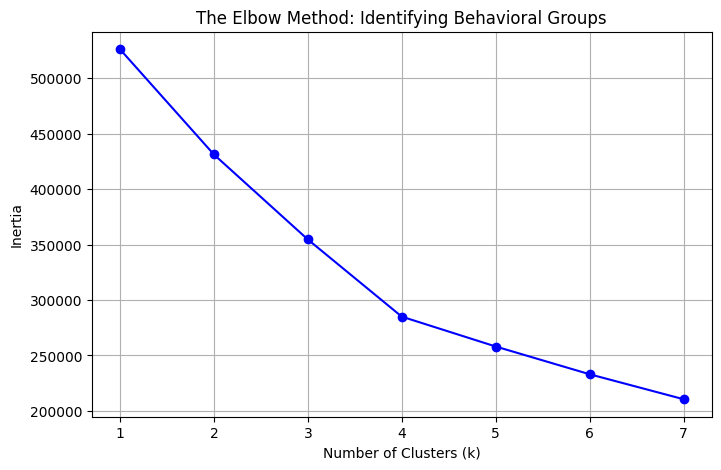

Cluster
2    32549
0    27988
1    23169
3    21493
Name: count, dtype: int64


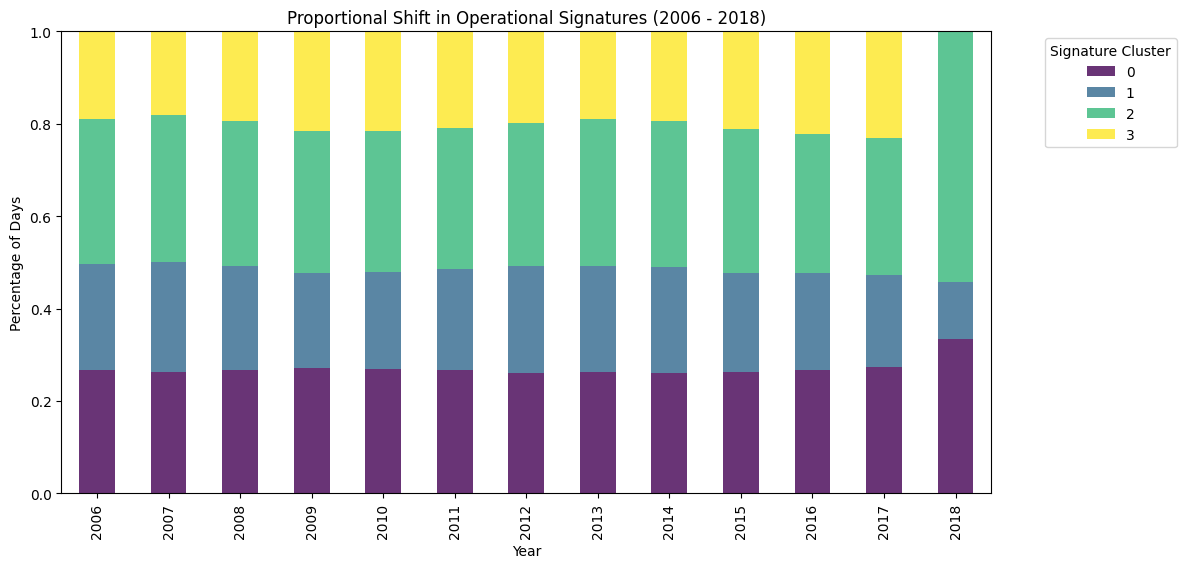

In [95]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



# Indices: PC2=1, PC3=2, PC4=3, PC5=4, PC9=8
scaler = StandardScaler()
behavioral_features = scaler.fit_transform(pca_results[:, [1, 2, 3, 4, 8]])

print(f"Clustering based on {behavioral_features.shape[1]} behavioral dimensions.")

inertia = []
K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(behavioral_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method: Identifying Behavioral Groups')
plt.grid(True)
plt.show()


# Assuming the elbow was at 3
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
plot_data['Cluster'] = kmeans.fit_transform(behavioral_features).argmax(axis=1)

# Quick check: How many days fall into each cluster?
print(plot_data['Cluster'].value_counts())


# Create a pivot table of Year vs Cluster frequency
cluster_trend = plot_data.groupby([plot_data['Datetime'].dt.year, 'Cluster']).size().unstack(fill_value=0)

# Normalize to percentages (0.0 to 1.0)
cluster_pct = cluster_trend.div(cluster_trend.sum(axis=1), axis=0)

# Plot the shift over the decade
cluster_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis', alpha=0.8)
plt.title('Proportional Shift in Operational Signatures (2006 - 2018)')
plt.ylabel('Percentage of Days')
plt.xlabel('Year')
plt.legend(title='Signature Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Matrix shape: (4383, 24) (Days x Hours)


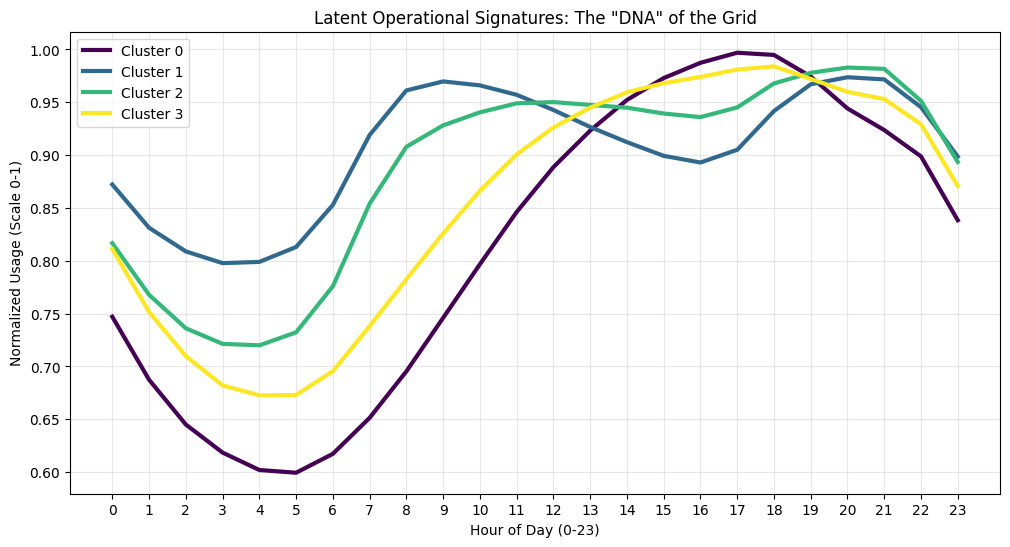

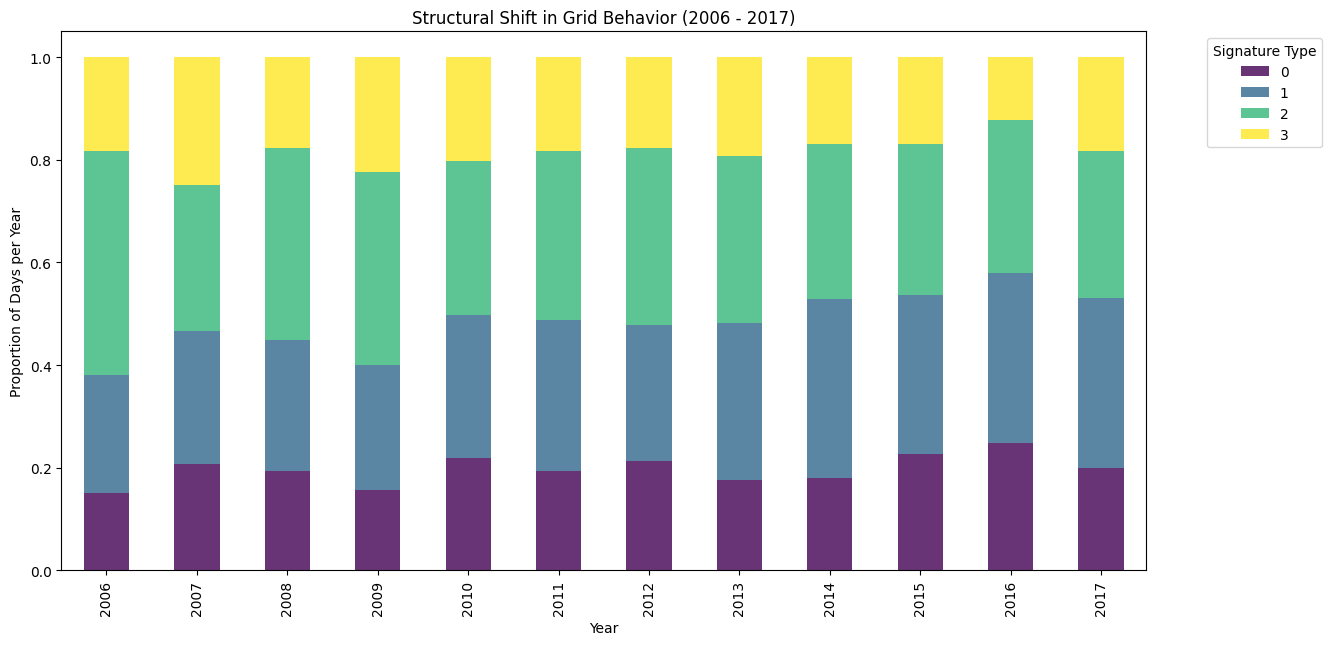

In [98]:
# 1. Clean the date range to avoid the 1-day 2018 outlier
mask = (test_data['Datetime'] >= '2006-01-01') & (test_data['Datetime'] <= '2017-12-31 23:00:00')
df_clean = test_data.loc[mask].copy()

# 2. Pivot: Rows = Date, Columns = Hour (0-23)
daily_matrix = df_clean.pivot_table(index=df_clean['Datetime'].dt.date, 
                                    columns=df_clean['Datetime'].dt.hour, 
                                    values='total_usage')

# 3. Normalize by Row: This captures the "Shape" only
# We divide every hour by that day's maximum usage
daily_shapes = daily_matrix.div(daily_matrix.max(axis=1), axis=0).fillna(0)

print(f"Matrix shape: {daily_shapes.shape} (Days x Hours)")

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# PCA to reduce the 24 hours into core shape components
pca_shapes = PCA(n_components=5)
pca_transformed_shapes = pca_shapes.fit_transform(daily_shapes)

# Cluster into 4 groups (Residential, Industrial, and 2 Hybrids)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
daily_matrix['Cluster'] = km.fit_predict(pca_transformed_shapes)

plt.figure(figsize=(12, 6))
colors = ['#440154', '#31688e', '#35b779', '#fde725'] # Match your previous chart colors

for i in range(4):
    cluster_mean = daily_shapes[daily_matrix['Cluster'] == i].mean()
    plt.plot(cluster_mean, label=f'Cluster {i}', color=colors[i], linewidth=3)

plt.title('Latent Operational Signatures: The "DNA" of the Grid')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Normalized Usage (Scale 0-1)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Re-attach the year for grouping
daily_matrix['Year'] = pd.to_datetime(daily_matrix.index).year

# Pivot and Normalize for the bar chart
shift_df = daily_matrix.groupby(['Year', 'Cluster']).size().unstack(fill_value=0)
shift_pct = shift_df.div(shift_df.sum(axis=1), axis=0)

# Plot
shift_pct.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors, alpha=0.8)
plt.title('Structural Shift in Grid Behavior (2006 - 2017)')
plt.ylabel('Proportion of Days per Year')
plt.legend(title='Signature Type', bbox_to_anchor=(1.05, 1))
plt.show()

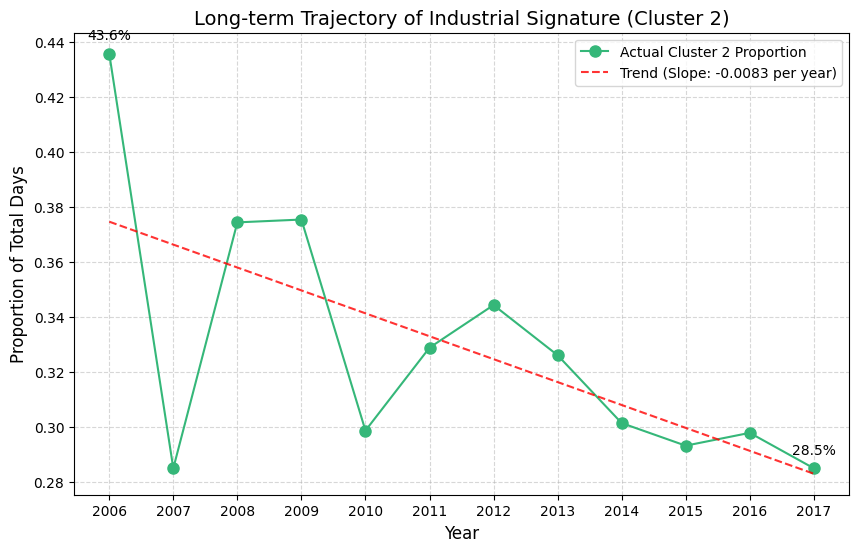

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the percentage data for Cluster 2
# (Assuming shift_pct is the DataFrame from your previous step)
industrial_trend = shift_pct[2] # Accessing Cluster 2 column
years = industrial_trend.index.values
proportions = industrial_trend.values

# 2. Calculate a Linear Regression (Trend Line)
z = np.polyfit(years, proportions, 1)
p = np.poly1d(z)

# 3. Plotting
plt.figure(figsize=(10, 6))

# Plot the actual data points
plt.plot(years, proportions, 'o-', color='#35b779', label='Actual Cluster 2 Proportion', markersize=8)

# Plot the trend line
plt.plot(years, p(years), "r--", alpha=0.8, label=f'Trend (Slope: {z[0]:.4f} per year)')

plt.title('Long-term Trajectory of Industrial Signature (Cluster 2)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Proportion of Total Days', fontsize=12)
plt.xticks(years)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Annotate the start and end for clarity
plt.annotate(f'{proportions[0]*100:.1f}%', (years[0], proportions[0]), textcoords="offset points", xytext=(0,10), ha='center')
plt.annotate(f'{proportions[-1]*100:.1f}%', (years[-1], proportions[-1]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()